# Retrieval, Method 2: Embedding Similarity (Item2Vec-style)

ALS (notebook 01) learns user *and* item vectors jointly by factorizing the interaction
matrix. Here we try something more flexible, borrowed straight from NLP: **word2vec's
skip-gram model, applied to items instead of words.**

The idea: treat each user's history as a "sentence" of items. Items that co-occur in the
same sentence (i.e. the same user interacted with both) should end up with similar
embeddings — exactly like words that appear in similar contexts end up with similar
embeddings in word2vec. Critically, this **only trains item embeddings**. There's no
notion of a "user embedding" learned directly at all.

So how do we recommend for a user? We build a user vector *on the fly*, at inference
time, simply by **averaging the embeddings of the items in their history**. This
"mean-pooling" trick is exactly what YouTube's original candidate-generation paper (Covington
et al., 2016) does for a user's watch history. It's cheap, requires no retraining when a
user interacts with something new, and works surprisingly well.

## The skip-gram objective

For every co-occurring pair of items $(i, j)$ from the same user's history, we want
$e_i \cdot e_j$ to be large. To stop every embedding from just collapsing to the same
vector (which would trivially make all dot products large), we also sample random
**negative** items $k$ that did *not* co-occur, and push $e_i \cdot e_k$ down. This is
**negative sampling**, and negatives are drawn from the item popularity distribution
raised to the 0.75 power — the same trick word2vec uses, which slightly flattens the
distribution so rare items still get sampled as negatives sometimes.

$$\mathcal{L} = -\log\sigma(e_i \cdot e_j) - \sum_{k=1}^{K} \log\sigma(-e_i \cdot e_k)$$

This is just binary cross-entropy: positive pairs get label 1, negative pairs get label 0.

In [2]:
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import rec_utils as ru

ru.setup_plot_style()
torch.manual_seed(0)

interactions, user_prefs, item_genres, item_pop = ru.generate_synthetic_data()
train, test = ru.leave_one_out_split(interactions)

n_users = interactions.user_id.max() + 1
n_items = interactions.item_id.max() + 1
seen = ru.user_seen_items(train)
user_items, item_users = ru.user_item_lists(train)

## Step 1 — build training pairs from co-occurrence

For each user, every *pair* of items in their (train) history is a positive example. With
~24 items per user that's `C(24, 2) = 276` pairs per user.

In [3]:
pairs = []
for u, items in user_items.items():
    for i, j in itertools.combinations(items, 2):
        pairs.append((i, j))
pairs = np.array(pairs)
print(f"{len(pairs):,} positive (item, item) co-occurrence pairs from {n_users} users")
pairs[:5]

165,600 positive (item, item) co-occurrence pairs from 600 users


array([[107, 325],
       [107, 212],
       [107, 193],
       [107, 209],
       [107,  93]])

## Step 2 — the model: shared item embedding table + negative sampling

One `nn.Embedding` table is all we need — the same table is used for both "sides" of a
pair, since co-occurrence is symmetric.

In [4]:
# item_counts returns a numpy array of counts for each item, filling missing items with 0 and sorted by item_id.
item_counts = train["item_id"].value_counts().reindex(range(n_items), fill_value=0).values.astype(np.float64) 

# neg_dist is the negative sampling distribution, which is computed by raising the item counts to the power of 0.75 
# and normalizing them to sum to 1. We first raise them to the power of 0.75 instead of 1 to reduce the influence of 
# very popular items, which can dominate the negative samples.
neg_dist = item_counts ** 0.75
neg_dist = neg_dist / neg_dist.sum()


dim = 16 # embedding dimension
n_neg = 5 # negative samples per positive pair. in other words, for each positive pair, we will sample 5 negative pairs as explained above
batch_size = 1024
n_epochs = 30

item_emb = nn.Embedding(n_items, dim)
nn.init.normal_(item_emb.weight, 0, 0.1)
optimizer = torch.optim.Adam(item_emb.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()
rng = np.random.default_rng(0)

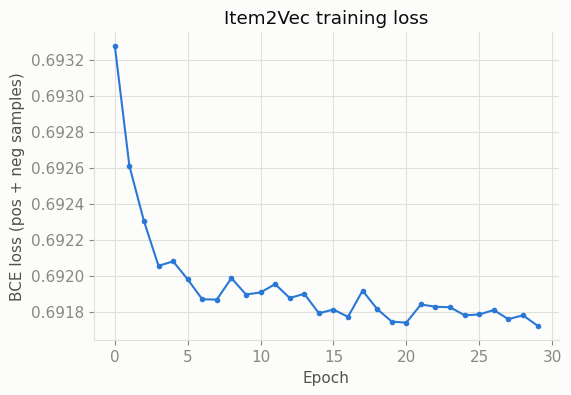

In [5]:
loss_history = []

for epoch in range(n_epochs):
    perm = rng.permutation(len(pairs)) # shuffle the pairs for each epoch
    epoch_loss, n_batches = 0.0, 0

    for start in range(0, len(pairs), batch_size):
        batch = pairs[perm[start:start + batch_size]] # select the batch
        i_idx = torch.as_tensor(batch[:, 0], dtype=torch.long) # select the first column of the batch as the positive item indices
        j_idx = torch.as_tensor(batch[:, 1], dtype=torch.long) # select the second column of the batch as the positive item indices
        # np.choice is a function that samples from a given array given a probability distribution.
        # In this case, we are sampling negative items from the range of n_items, 
        # with a size of (len(batch), n_neg) and a probability distribution of neg_dist.
        # It may happen that i or j is sampled as a negative item, but this is not a problem since the loss function will 
        # still be able to learn from the positive pairs.
        neg_idx = torch.as_tensor(
            rng.choice(n_items, size=(len(batch), n_neg), p=neg_dist), dtype=torch.long) # sample negative items

        ei, ej, en = item_emb(i_idx), item_emb(j_idx), item_emb(neg_idx)
        # Compute the loss for the positive and negative pairs. 
        # The positive pairs are the dot product of the embeddings of the two items in the pair, 
        # while the negative pairs are the dot product of the embedding of the first item in the pair 
        # and the embeddings of the negative samples.
        pos_logits = (ei * ej).sum(-1)                       # (B,)
        neg_logits = torch.einsum("bd,bkd->bk", ei, en)      # (B, n_neg)

        logits = torch.cat([pos_logits.unsqueeze(1), neg_logits], dim=1) # concatenate the positive and the negative logits
        labels = torch.zeros_like(logits) # create a tensor of zeros with the same shape as logits
        labels[:, 0] = 1.0 # first column = positive, the rest (with size n_neg) = negative

        loss = loss_fn(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    loss_history.append(epoch_loss / n_batches)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history, color=ru.SEQUENTIAL_BLUE[3], marker="o", markersize=3)
ax.set_title("Item2Vec training loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE loss (pos + neg samples)")
plt.show()

The loss starts right at $\ln 2 \approx 0.693$ (random guessing between positive and
negative) and drops from there — a much smaller move than a typical classifier, but
that's expected: with only ~25 interactions per user, there's a hard ceiling on how
separable co-occurrence pairs can be. What matters is whether it's *enough* to beat
popularity, which we check below.

## Sanity check: genre clusters again

Same check as notebook 01 — the item embeddings never saw genre labels, only
co-occurrence.

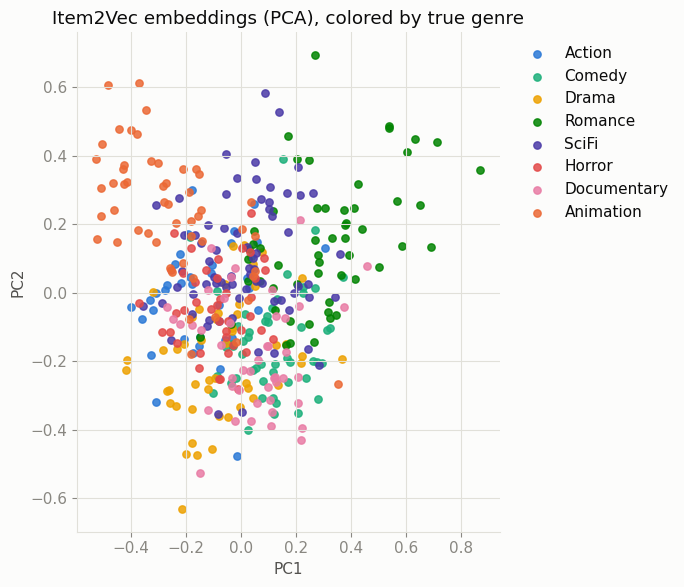

In [6]:
Y = item_emb.weight.detach().numpy()
dominant_genre = item_genres.argmax(axis=1)
coords = PCA(n_components=2, random_state=0).fit_transform(Y)

fig, ax = plt.subplots(figsize=(7, 6))
for g in range(ru.N_GENRES):
    mask = dominant_genre == g
    ax.scatter(coords[mask, 0], coords[mask, 1], s=28,
               color=ru.GENRE_COLORS[g], label=ru.GENRE_NAMES[g], alpha=0.85)
ax.set_title("Item2Vec embeddings (PCA), colored by true genre")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

## Step 3 — from item embeddings to a user vector: mean pooling

No user embedding was ever trained. Instead, a user's vector is just the **average of the
embeddings of the items in their history** — a zero-training way to represent a user, and
one that updates immediately as soon as the user interacts with something new (no need to
retrain to refresh a user's recommendations).

Retrieval is then nearest-neighbor search: cosine similarity between the user vector and
every item vector.

In [7]:
Y_norm = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-8)

# To compute the top 5 recommended items for one user, for example user 0:
# First we compute the user vector by averaging the embeddings of the items that each user has interacted with.
user_vecs = np.zeros((n_users, dim))
for u, items in user_items.items():
    user_vecs[u] = Y_norm[items].mean(axis=0) # for each user we compute the average of normalize item embeddings.

# Second, we compute the cosine similarity between the user vector and all item vectors, 
# and select the top 5 items with the highest similarity.
user_id = 0
user_vec = user_vecs[user_id]

# Third, compute the dot product between the user vector and all item vectors, 
# since it is normalized, it is equivalent to cosine similarity.
user_sim = Y_norm @ user_vec 
top_k = 5
user_top_items = np.argsort(user_sim)[::-1][:top_k] # argsort returns the indices that would sort an array. We reverse it to get the top items with highest similarity.
user_top_items

array([177, 259,  74,  56, 248])

In [8]:
# another apprroach to recommend items would be to check the last item that the user has watched:
user_last_item = user_items[user_id][-1] # get the last item that the user has watched
user_last_item_emb = Y_norm[user_last_item] # get the embedding of the last item that the user has watched
user_last_item_sim = Y_norm @ user_last_item_emb # compute the dot product (cosine similarity) between the last item embedding and all item embeddings
top_k = 5
user_last_item_top_items = np.argsort(user_last_item_sim)[::-1][:top_k] # argsort returns the indices that would sort an array. We reverse it to get the top items with highest similarity.
user_last_item_top_items

array([ 29, 295, 112, 245, 155])

In [9]:
Y_norm = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-8)
# we normalyze the user vectors to have unit length, so that we can compute cosine similarity between users and items.

user_vecs = np.zeros((n_users, dim))
for u, items in user_items.items():
    user_vecs[u] = Y[items].mean(axis=0)
user_vecs_norm = user_vecs / (np.linalg.norm(user_vecs, axis=1, keepdims=True) + 1e-8)

def recommend_item2vec(user_id, n):
    scores = user_vecs_norm[user_id] @ Y_norm.T   # cosine similarity
    return ru.rank_topn(scores, seen.get(user_id, set()), n)

metrics = ru.evaluate_recommender(recommend_item2vec, train, test, k_list=(10, 20))
ru.save_results("02_item2vec", metrics)

results_so_far = ru.load_all_results()
pd.DataFrame(results_so_far).T

Saved results to d:\Pablo_Data\Documentos\VSCode\revolut\recommendation_algorithms\results\02_item2vec.json


,recall@10,ndcg@10,recall@20,ndcg@20
00_popularity,0.051667,0.029234,0.085000,0.037774
01_als,0.108333,0.062281,0.168333,0.077169
02_item2vec,0.121667,0.055420,0.176667,0.069363
03_gbdt_ranking,0.115000,0.062243,0.190000,0.081075
04_two_tower,0.095000,0.051513,0.163333,0.068416


## ALS vs. Item2Vec: same goal, different route

| | ALS | Item2Vec + mean pooling |
|---|---|---|
| Learns | user *and* item vectors jointly | item vectors only |
| Training signal | the full user-item matrix, confidence-weighted | co-occurrence pairs within a user's history |
| User representation | a learned parameter | computed on the fly (average of item vectors) |
| New interaction for existing user | needs retraining (or an incremental update) to refresh $x_u$ | user vector updates instantly, no retraining |
| New item, zero interactions | no embedding at all (cold start) | same problem — still needs at least one co-occurrence |

Both are valid, widely-used retrieval methods; the mean-pooling trick is especially handy
in systems with fast-changing user history (e.g. session-based recommendations) where
retraining a full matrix factorization on every user action isn't realistic.

Next: `03_ranking_gbdt.ipynb` takes a retrieval model's candidates and learns to re-rank
them with a gradient-boosted tree model and richer features.